In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../data/processed/california_housing_milestone1.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,price_category
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,2
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,2
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,2


Remider of the price_category map `category_map = {"Low": 0, "Medium": 1, "High": 2}`

In [3]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
price_category          0
dtype: int64

In [4]:
# Check missing values
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

print("Missing values per column:")
print(missing_counts[missing_counts > 0])
print("\nPercentage of missing values per column:")
print(missing_percent[missing_percent > 0])

Missing values per column:
total_bedrooms    207
dtype: int64

Percentage of missing values per column:
total_bedrooms    1.002907
dtype: float64


In [5]:
# Handle missing values
# For numerical columns, use median imputation.
# For categorical columns, use mode imputation.
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum().sum())


Missing values after handling:
0


The original dataset has missing values only in the `total_bedrooms` feature. We use median imputation, which is appropriate for numerical variables because it is more robust to skewness and extreme values than the mean.

## Dealing with outliers

In [6]:
numerical_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | 
            (df[numerical_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()

longitude                0
latitude                 0
housing_median_age       0
total_rooms           1287
total_bedrooms        1306
population            1196
households            1220
median_income          681
median_house_value    1071
price_category           0
dtype: int64

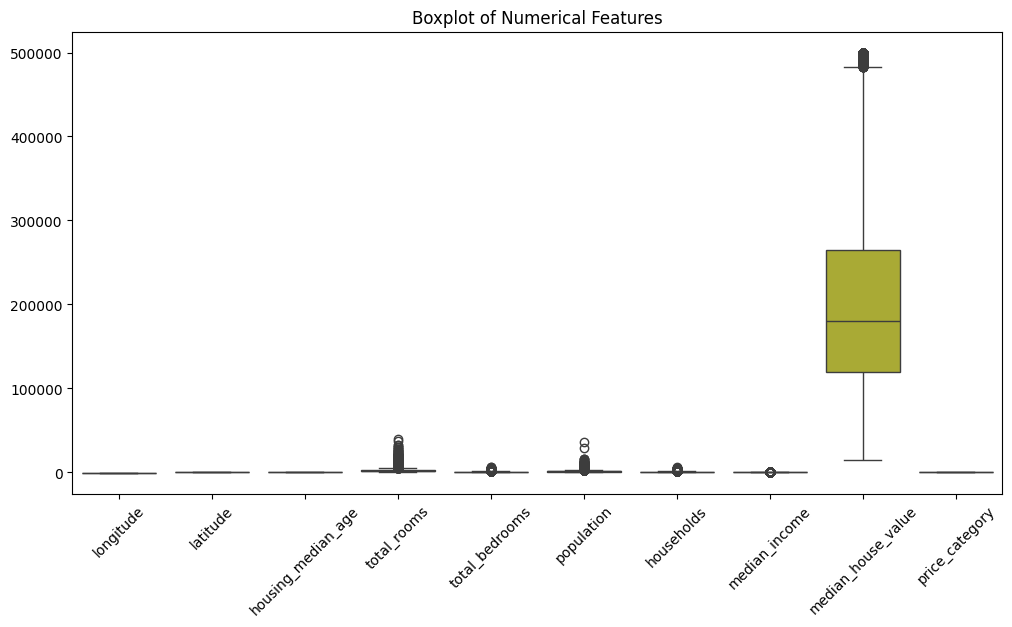

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [8]:
cols_to_cap = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value"
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)

Outliers were detected using the Interquartile Range (IQR) method. Several count‑based and economic variables exhibited a large number of outliers, which is expected given the aggregated nature of housing and population data. These extreme values represent valid observations rather than errors. Therefore, outliers were treated using capping (winsorization) instead of removal to reduce their influence while preserving the full dataset.

Confirmation

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_after = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | 
                  (df[numerical_cols] > (Q3 + 1.5 * IQR)))

outliers_after.sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
price_category        0
dtype: int64

## Summary statistics

In [10]:
df[numerical_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,price_category
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2441.692472,501.182086,1336.959012,469.020107,3.801010,205981.224976,0.999806
std,2.003532,2.135952,12.585558,1397.790038,284.133641,765.550830,265.507540,1.657658,113217.350152,0.816635
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,0.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,1.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,2.000000
max,-114.310000,41.950000,52.000000,5698.375000,1162.625000,3132.000000,1092.500000,8.013025,482412.500000,2.000000


### Box plots

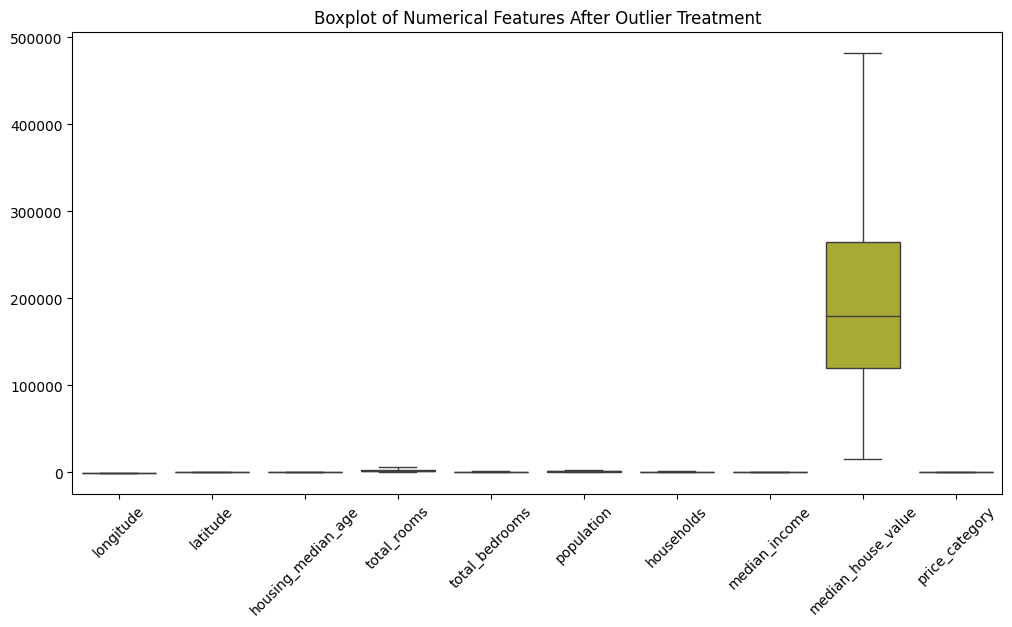

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features After Outlier Treatment")
plt.show()

After treating outliers using the IQR‑based capping method, the dataset was re‑evaluated to confirm the effectiveness of the treatment. The IQR outlier detection was re‑applied, showing a significant reduction in extreme values. Summary statistics and boxplots further confirmed that the influence of extreme observations was reduced while preserving the overall data distribution.

## Engineer at least three (3) new features, explaining Why each new feature may improve model performance

Feature scaling was performed using StandardScaler to standardize numerical features to zero mean and unit variance. Scaling is critical for Support Vector Machines because SVM relies on distance calculations, and unscaled features can dominate the decision boundary. It is also essential for Lasso regression, as L1 regularization penalizes coefficients based on their magnitude; without scaling, features with larger numeric ranges would be penalized more heavily, leading to biased feature selection. Therefore, feature scaling ensures fair contribution of all features and improves model performance and stability.

In [12]:
# Feature engineering
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]
df["income_per_household_member"] = df["median_income"] / df["households"]

Verifying the new features were created

In [13]:
df[[
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "income_per_household_member"
]].describe()

,rooms_per_household,bedrooms_per_room,population_per_household,income_per_household_member
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,5.395396,0.213592,3.000738,0.014980
std,2.404376,0.063380,5.200718,0.073115
min,0.846154,0.076338,0.692308,0.000620
25%,4.487007,0.177594,2.451816,0.005108
50%,5.215904,0.204027,2.849303,0.008434
75%,5.961572,0.237378,3.248158,0.014047
max,141.909091,2.824675,522.000000,8.013025


Four features were engineered to improve model performance.
- Rooms per household was created to represent housing space availability, capturing living conditions more effectively than raw room counts.
- Bedrooms per room was engineered to reflect housing layout efficiency and structural characteristics.
- Population per household was introduced to measure household crowding, which is closely related to socio economic conditions and housing prices.
- Income per household member is introduced as an income-density feature.

These engineered features provide more informative representations of the data and help machine learning models learn meaningful relationships.

## Performing feature selection by dropping irrelevant or redundant features

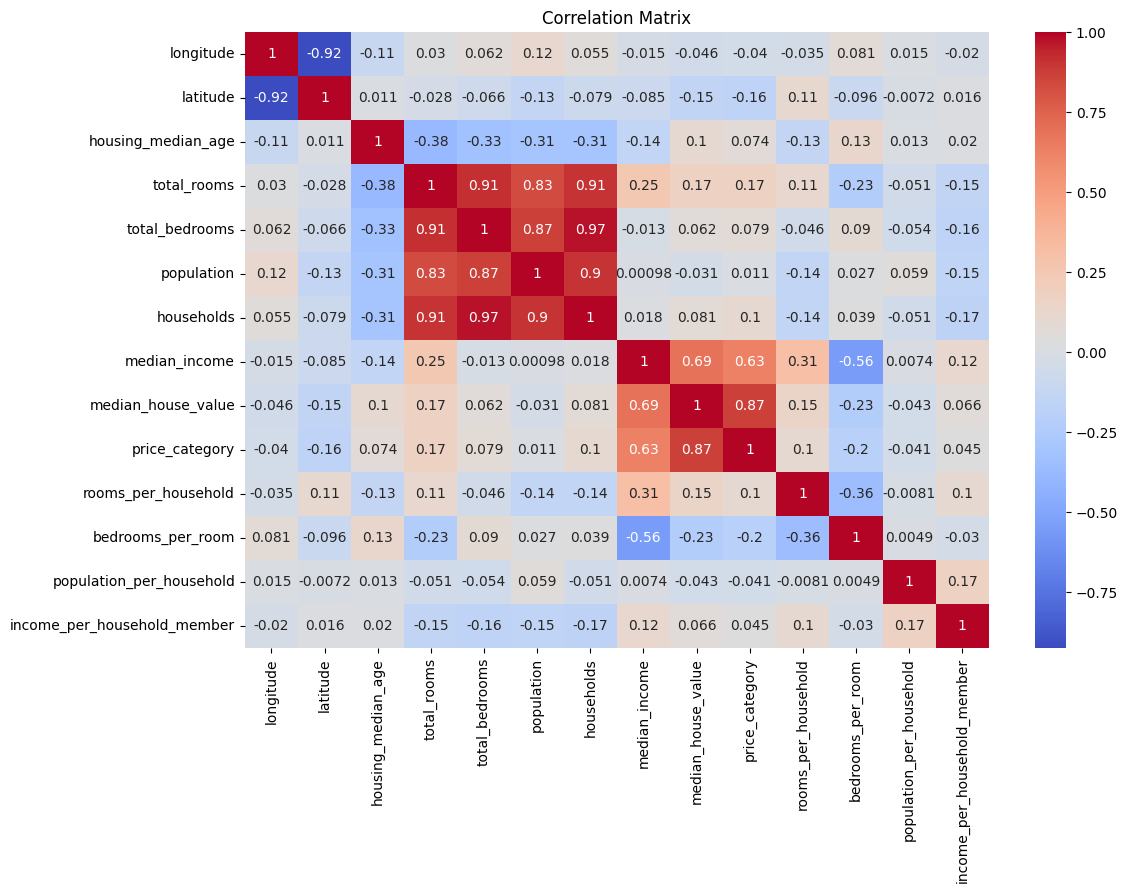

In [15]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Feature selection was performed after feature engineering to remove redundant and less informative variables. Features such as
- total rooms
- total bedrooms
- population
- households

These were dropped because they represent block level aggregates and are strongly correlated with one another. These variables were replaced by ratio based engineered features such as rooms per household, bedrooms per room, and population per household, which provide normalized and more meaningful representations of housing density, layout efficiency, and crowding. This reduced multicollinearity, simplified the feature space, and improved model interpretability and performance.

In [16]:
features_to_drop = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households"
]

df = df.drop(columns=features_to_drop)

## Performing feature scaling and explain why scaling is critical for SVM and Lasso

In [ ]:

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# One-hot encode categorical variable
X = pd.get_dummies(X, columns=["ocean_proximity"], drop_first=True)

# Train-test split before scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = X_train.select_dtypes(include=[np.number]).columns
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Feature scaling completed.")

### Confirmation for the dropped features

In [ ]:
for col in ["total_rooms", "total_bedrooms", "population", "households"]:
    print(col, "exists" if col in df.columns else "dropped")

## Regression Target

In [ ]:
#Separating the  features and target


X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

#Performing  the train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset is split into training and test sets using an 80:20 ratio. The training set will be used to fit the models, while the test set is reserved for evaluating performance on unseen data. This split provides a good balance between having sufficient data for learning and obtaining a reliable estimate of generalization performance. A fixed random state is used to ensure reproducibility of results.

In [ ]:
feature_names = X.columns.tolist()

print(len(feature_names)) 

In [17]:
# Regression target
y_reg = df["median_house_value"]

# Features
X_reg = df.drop(columns=["median_house_value"])

num_cols = X_reg.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_reg.select_dtypes(exclude=np.number).columns.tolist()

In [18]:
num_cols, cat_cols

(['longitude',
  'latitude',
  'housing_median_age',
  'median_income',
  'price_category',
  'rooms_per_household',
  'bedrooms_per_room',
  'population_per_household',
  'income_per_household_member'],
 ['ocean_proximity'])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [21]:
# Save processed data to be used in Lasso Regression notebook
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

## Classification Target

In [ ]:
y_clf = df["price_category"]
X_clf = df.drop(columns=["median_house_value", "price_category"])

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Save processed data to be used in SVM Classification notebook
X_train.to_csv('../data/processed/classification/X_train_clf.csv', index=False)
X_test.to_csv('../data/processed/classification/X_test_clf.csv', index=False)
y_train.to_csv('../data/processed/classification/y_train_clf.csv', index=False)
y_test.to_csv('../data/processed/classification/y_test_clf.csv', index=False)